In [1]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


character(0)

# Lab Problem Statement 6: Statistical Analysis of Physical Characteristics of Palmer Penguins

## Objective

To perform statistical analysis on the Palmer Penguins dataset to determine whether physical characteristics such as body mass and flipper length differ significantly across penguin species and sex.

## Statistical Methods

- Descriptive Statistics
- Histogram, Boxplot and Density Plot
- Shapiro-Wilk Normality Test
- Q-Q Plot
- Independent Two-Sample Welch t-Test
- 95% Confidence Interval
- Cohen's d Effect Size
- One-Way ANOVA
- Levene's Test
- Tukey's HSD Post-Hoc Test
- Kruskal-Wallis Test
- Two-Way ANOVA
- Interaction Analysis
- Flipper-Length Analysis

## Dataset

The Palmer Penguins dataset contains physical measurements of 344 penguins belonging to three species:

- Adelie
- Chinstrap
- Gentoo

### Variables Used

| Variable | Description |
|---|---|
| species | Penguin species |
| island | Island where the penguin was observed |
| sex | Penguin sex |
| bill_length_mm | Bill length in millimetres |
| bill_depth_mm | Bill depth in millimetres |
| flipper_length_mm | Flipper length in millimetres |
| body_mass_g | Body mass in grams |

## 1. Setup and Required Packages

In [3]:
# Install required packages
required_packages <- c(
  "palmerpenguins",
  "tidyverse",
  "moments",
  "car",
  "rstatix",
  "effectsize"
)

for (pkg in required_packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg, repos = "https://cloud.r-project.org")
  }
}

# Load packages
library(palmerpenguins)
library(tidyverse)
library(moments)
library(car)
library(rstatix)
library(effectsize)

# Reproducibility
set.seed(123)

## 2. Load the Palmer Penguins Dataset

In [4]:
# Load the Palmer Penguins dataset
data("penguins")

# Create working copy
penguin_data <- penguins

# Display first six observations
head(penguin_data)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007


In [6]:
# Dataset dimensions
cat("Number of observations:", nrow(penguin_data), "\n")
cat("Number of variables:", ncol(penguin_data), "\n")

# Dataset structure
str(penguin_data)

Number of observations: 344 
Number of variables: 8 
tibble [344 × 8] (S3: tbl_df/tbl/data.frame)
 $ species          : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island           : Factor w/ 3 levels "Biscoe","Dream",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ bill_length_mm   : num [1:344] 39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ bill_depth_mm    : num [1:344] 18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipper_length_mm: int [1:344] 181 186 195 NA 193 190 181 195 193 190 ...
 $ body_mass_g      : int [1:344] 3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex              : Factor w/ 2 levels "female","male": 2 1 1 NA 1 2 1 2 NA NA ...
 $ year             : int [1:344] 2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...


## 3. Data Exploration and Missing Values

In [7]:
# Summary of dataset
summary(penguin_data)

# Missing values in each variable
colSums(is.na(penguin_data))

      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NA's   :2       NA's   :2      
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NA's  : 11   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  
 NA's   :2         NA's   :2                  

species            island    bill_length_mm     bill_depth_mm 
                0                 0                 2                 2 
flipper_length_mm       body_mass_g               sex              year 
                2                 2                11                 0

In [8]:
# Species frequency
table(penguin_data$species)

# Sex frequency
table(penguin_data$sex)

# Species and sex frequency
table(penguin_data$species, penguin_data$sex)


   Adelie Chinstrap    Gentoo 
      152        68       124 


female   male 
   165    168 

           
            female male
  Adelie        73   73
  Chinstrap     34   34
  Gentoo        58   61

## 4. Data Cleaning

Rows containing missing values in the variables required for the analysis are removed.

In [9]:
# Select variables required for analysis
analysis_data <- penguin_data %>%
  select(
    species,
    island,
    sex,
    bill_length_mm,
    bill_depth_mm,
    flipper_length_mm,
    body_mass_g
  ) %>%
  drop_na()

# Check cleaned dataset
dim(analysis_data)

# Check remaining missing values
colSums(is.na(analysis_data))

[1] 333   7

species            island               sex    bill_length_mm 
                0                 0                 0                 0 
    bill_depth_mm flipper_length_mm       body_mass_g 
                0                 0                 0

# Task 1: Descriptive Statistical Analysis

Descriptive statistics are calculated for penguin body mass.

The following measures are calculated:

- Mean
- Median
- Minimum
- Maximum
- Variance
- Standard Deviation
- First Quartile
- Third Quartile
- Interquartile Range
- Skewness
- Kurtosis

## 5. Overall Descriptive Statistics of Body Mass

In [10]:
body_mass_summary <- analysis_data %>%
  summarise(
    N = n(),
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Minimum = min(body_mass_g),
    Maximum = max(body_mass_g),
    Variance = var(body_mass_g),
    Standard_Deviation = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )

body_mass_summary

N,Mean,Median,Minimum,Maximum,Variance,Standard_Deviation,Q1,Q3,IQR,Skewness,Kurtosis
<int>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
333,4207.057,4050,2700,6300,648372.5,805.2158,3550,4775,1225,0.4701162,2.259514


## 6. Species-Wise Descriptive Statistics of Body Mass

In [11]:
species_summary <- analysis_data %>%
  group_by(species) %>%
  summarise(
    N = n(),
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Minimum = min(body_mass_g),
    Maximum = max(body_mass_g),
    Variance = var(body_mass_g),
    Standard_Deviation = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g),
    .groups = "drop"
  )

species_summary

species,N,Mean,Median,Minimum,Maximum,Variance,Standard_Deviation,Q1,Q3,IQR,Skewness,Kurtosis
<fct>,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Adelie,146,3706.164,3700,2850,4775,210332.4,458.6201,3362.5,4000,637.5,0.2770077,2.411479
Chinstrap,68,3733.088,3700,2700,4800,147713.5,384.3351,3487.5,3950,462.5,0.2419413,3.463681
Gentoo,119,5092.437,5050,3950,6300,251478.3,501.4762,4700.0,5500,800.0,0.0449965,2.242850


## 7. Histogram of Body Mass

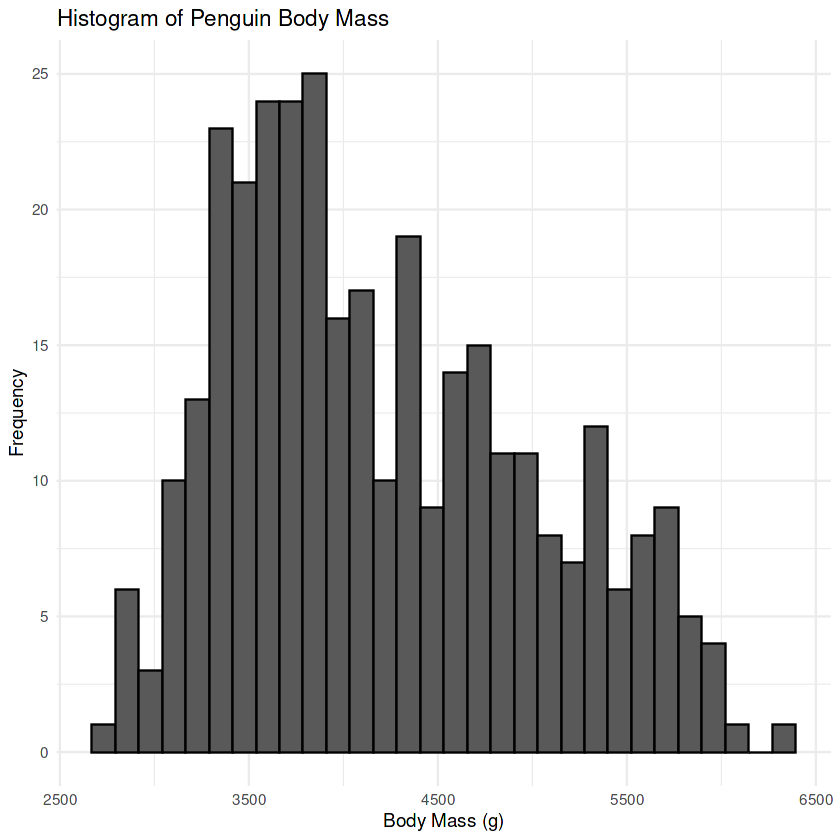

In [12]:
ggplot(analysis_data, aes(x = body_mass_g)) +
  geom_histogram(
    bins = 30,
    color = "black"
  ) +
  labs(
    title = "Histogram of Penguin Body Mass",
    x = "Body Mass (g)",
    y = "Frequency"
  ) +
  theme_minimal()

## 8. Density Plot of Body Mass by Species

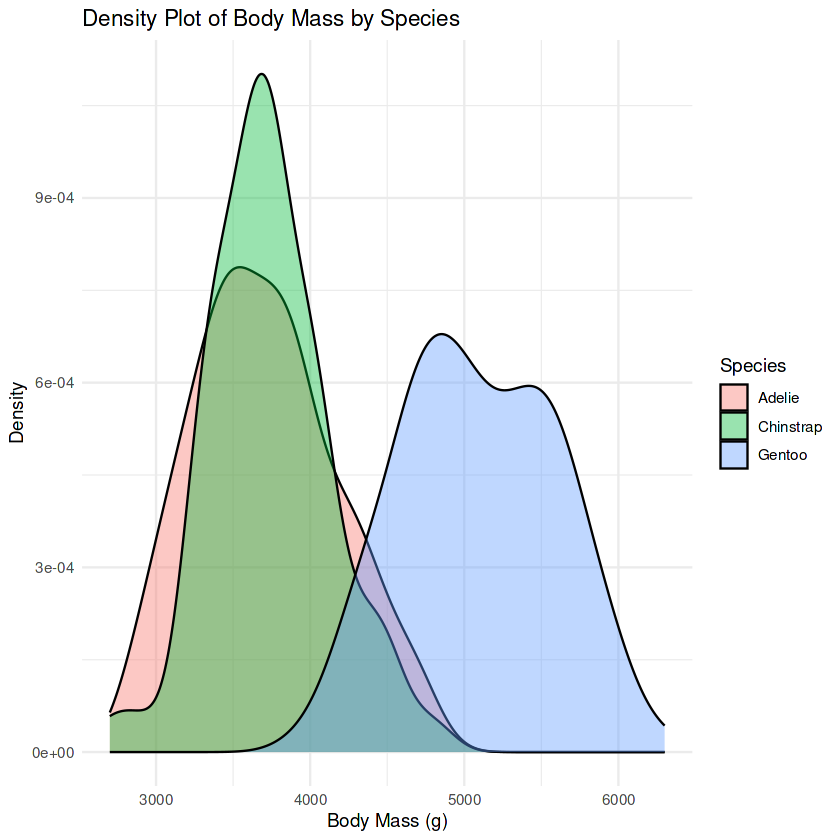

In [13]:
ggplot(
  analysis_data,
  aes(x = body_mass_g, fill = species)
) +
  geom_density(alpha = 0.4) +
  labs(
    title = "Density Plot of Body Mass by Species",
    x = "Body Mass (g)",
    y = "Density",
    fill = "Species"
  ) +
  theme_minimal()

## 9. Species-Wise Boxplot of Body Mass

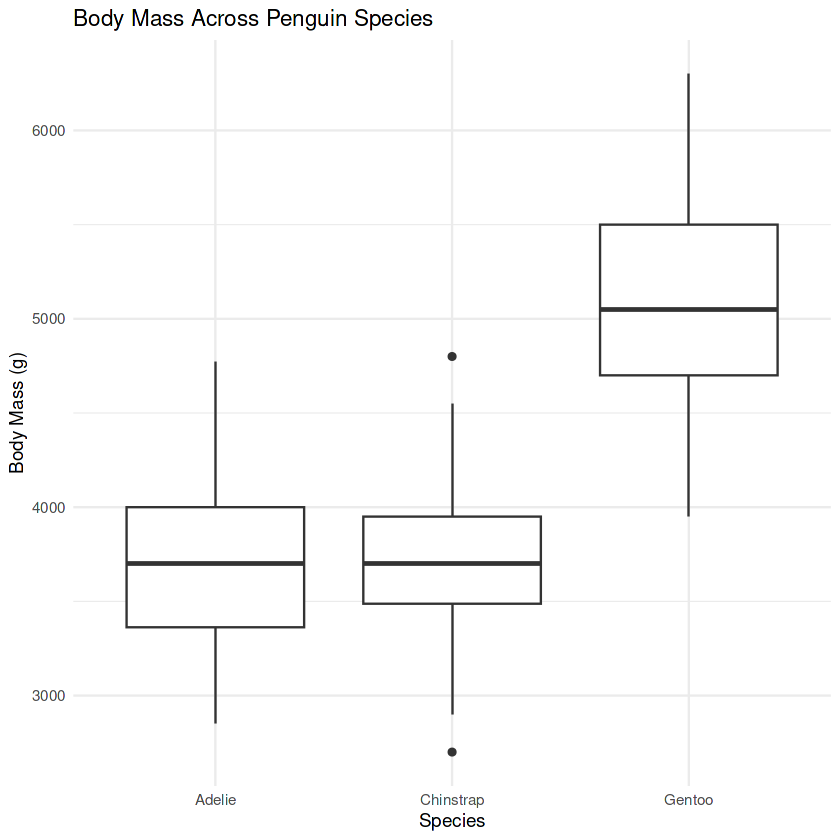

In [14]:
ggplot(
  analysis_data,
  aes(x = species, y = body_mass_g)
) +
  geom_boxplot() +
  labs(
    title = "Body Mass Across Penguin Species",
    x = "Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

# Task 2: Hypothesis Testing

## Male vs Female Body Mass

### Null Hypothesis (H₀)

There is no significant difference between the mean body mass of male and female penguins.

$$
H_0: \mu_{male} = \mu_{female}
$$

### Alternative Hypothesis (H₁)

There is a significant difference between the mean body mass of male and female penguins.

$$
H_1: \mu_{male} \neq \mu_{female}
$$

The significance level is:

$$
\alpha = 0.05
$$

An independent two-sample Welch t-test is used because male and female penguins are independent observations.

## 10. Sex-Wise Descriptive Statistics

In [15]:
sex_summary <- analysis_data %>%
  group_by(sex) %>%
  summarise(
    N = n(),
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Standard_Deviation = sd(body_mass_g),
    Variance = var(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    .groups = "drop"
  )

sex_summary

sex,N,Mean,Median,Standard_Deviation,Variance,Q1,Q3,IQR
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
female,165,3862.273,3650,666.1720,443785.2,3350,4550.0,1200.0
male,168,4545.685,4300,787.6289,620359.3,3900,5312.5,1412.5


## 11. Sex-Wise Boxplot of Body Mass

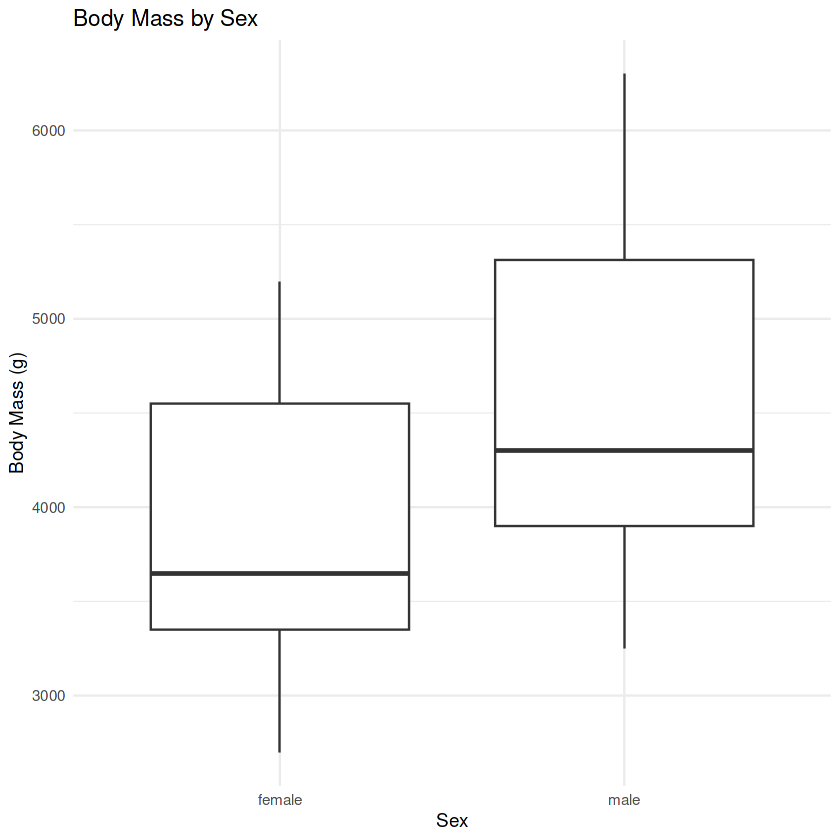

In [16]:
ggplot(
  analysis_data,
  aes(x = sex, y = body_mass_g)
) +
  geom_boxplot() +
  labs(
    title = "Body Mass by Sex",
    x = "Sex",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

## 12. Shapiro-Wilk Normality Test

### Hypotheses

**H₀:** The data are normally distributed.

**H₁:** The data are not normally distributed.

At α = 0.05:

- p-value > 0.05: Fail to reject H₀
- p-value ≤ 0.05: Reject H₀

In [17]:
# Male body mass
male_mass <- analysis_data %>%
  filter(sex == "male") %>%
  pull(body_mass_g)

# Female body mass
female_mass <- analysis_data %>%
  filter(sex == "female") %>%
  pull(body_mass_g)

# Shapiro-Wilk tests
shapiro_male <- shapiro.test(male_mass)
shapiro_female <- shapiro.test(female_mass)

shapiro_male
shapiro_female


	Shapiro-Wilk normality test

data:  male_mass
W = 0.92504, p-value = 1.227e-07



	Shapiro-Wilk normality test

data:  female_mass
W = 0.91931, p-value = 6.155e-08


## 13. Q-Q Plot for Male Body Mass

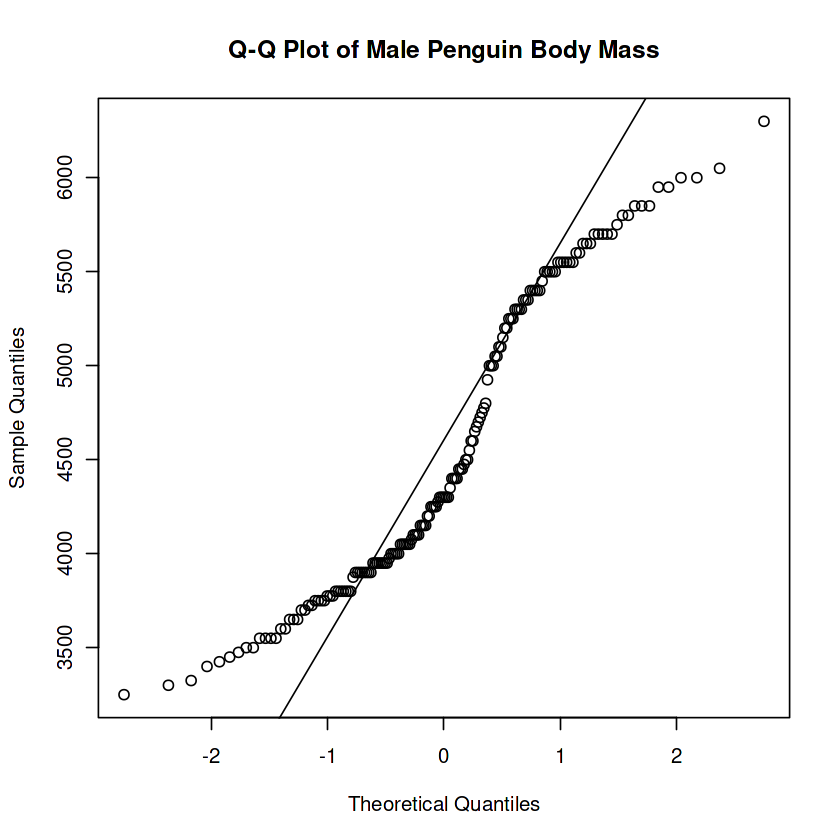

In [18]:
qqnorm(
  male_mass,
  main = "Q-Q Plot of Male Penguin Body Mass"
)

qqline(male_mass)

## 14. Q-Q Plot for Female Body Mass

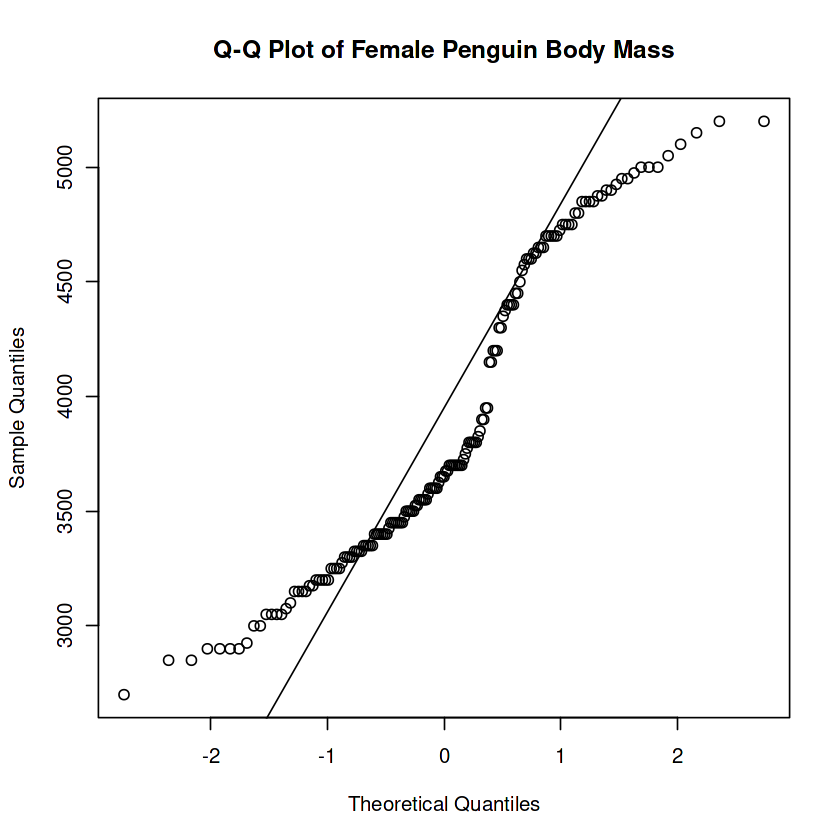

In [19]:
qqnorm(
  female_mass,
  main = "Q-Q Plot of Female Penguin Body Mass"
)

qqline(female_mass)

## 15. Independent Two-Sample Welch t-Test

In [20]:
t_test <- t.test(
  body_mass_g ~ sex,
  data = analysis_data,
  var.equal = FALSE,
  conf.level = 0.95
)

t_test


	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 


## 16. t-Test Results

The following values are reported:

- t-statistic
- Degrees of freedom
- p-value
- 95% confidence interval
- Difference between group means

In [21]:
cat("t-statistic =", round(t_test$statistic, 4), "\n")
cat("Degrees of freedom =", round(t_test$parameter, 4), "\n")
cat("p-value =", format.pval(t_test$p.value, digits = 5), "\n")

cat(
  "95% Confidence Interval =",
  round(t_test$conf.int[1], 2),
  "to",
  round(t_test$conf.int[2], 2),
  "g\n"
)

cat(
  "Mean of first group =",
  round(t_test$estimate[1], 2),
  "g\n"
)

cat(
  "Mean of second group =",
  round(t_test$estimate[2], 2),
  "g\n"
)

t-statistic = -8.5545 
Degrees of freedom = 323.8959 
p-value = 4.7939e-16 
95% Confidence Interval = -840.58 to -526.25 g
Mean of first group = 3862.27 g
Mean of second group = 4545.68 g


## 17. Cohen's d Effect Size

Cohen's d is used to measure the standardized difference between male and female body mass.

### Interpretation

| Cohen's d | Effect |
|---|---|
| 0.2 | Small |
| 0.5 | Medium |
| 0.8 | Large |

In [52]:
# Separate male and female body mass
male_mass <- analysis_data %>%
  filter(sex == "male") %>%
  pull(body_mass_g)

female_mass <- analysis_data %>%
  filter(sex == "female") %>%
  pull(body_mass_g)

# Sample sizes
n_male <- length(male_mass)
n_female <- length(female_mass)

# Means
mean_male <- mean(male_mass)
mean_female <- mean(female_mass)

# Standard deviations
sd_male <- sd(male_mass)
sd_female <- sd(female_mass)

# Pooled standard deviation
pooled_sd <- sqrt(
  (
    (n_male - 1) * sd_male^2 +
    (n_female - 1) * sd_female^2
  ) /
  (n_male + n_female - 2)
)

# Cohen's d
cohen_d <- (mean_male - mean_female) / pooled_sd

# Display results
cat("Male mean =", round(mean_male, 2), "g\n")
cat("Female mean =", round(mean_female, 2), "g\n")
cat("Pooled SD =", round(pooled_sd, 2), "g\n")
cat("Cohen's d =", round(cohen_d, 4), "\n")

Male mean = 4545.68 g
Female mean = 3862.27 g
Pooled SD = 729.98 g
Cohen's d = 0.9362 


In [53]:
## Interpretation of Cohen's d

cat("Cohen's d =", round(cohen_d, 4), "\n")

if (abs(cohen_d) < 0.2) {
  cat("Effect size: Negligible\n")
} else if (abs(cohen_d) < 0.5) {
  cat("Effect size: Small\n")
} else if (abs(cohen_d) < 0.8) {
  cat("Effect size: Medium\n")
} else {
  cat("Effect size: Large\n")
}

Cohen's d = 0.9362 
Effect size: Large


## 18. Interpretation of t-Test

If the p-value is less than 0.05, the null hypothesis is rejected and there is a statistically significant difference in mean body mass between male and female penguins.

The 95% confidence interval provides the plausible range for the difference in mean body mass.

Cohen's d indicates the magnitude of the difference.

# Task 3: One-Way ANOVA

The objective is to determine whether mean body mass differs among Adelie, Chinstrap, and Gentoo penguins.

### Null Hypothesis (H₀)

$$
\mu_{Adelie} = \mu_{Chinstrap} = \mu_{Gentoo}
$$

### Alternative Hypothesis (H₁)

At least one species has a different mean body mass.

The significance level is α = 0.05.

## 19. Distribution of Body Mass by Species

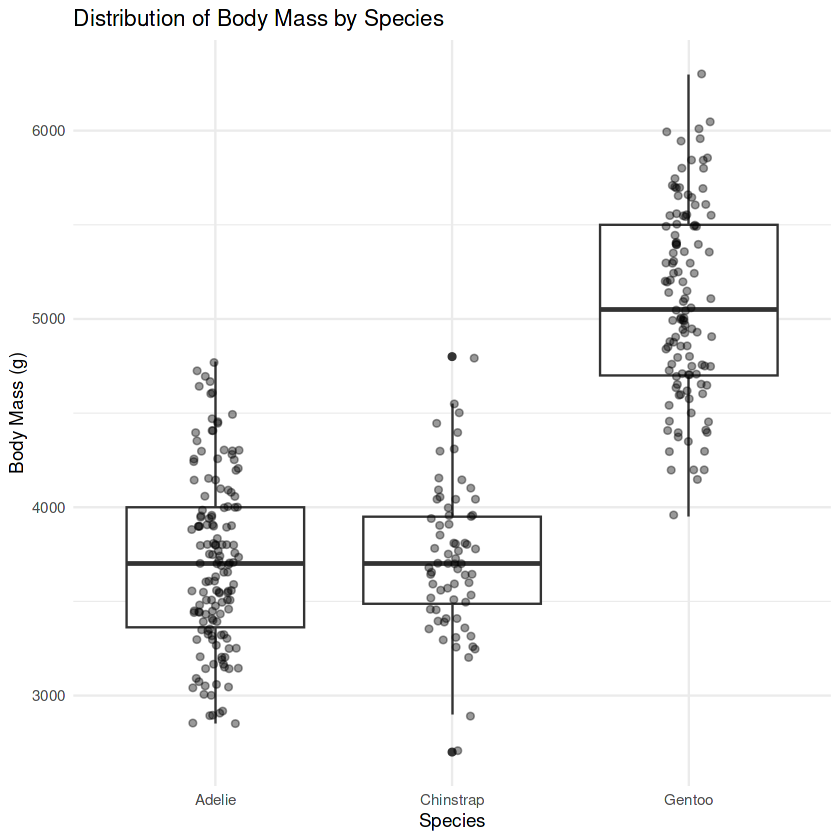

In [24]:
ggplot(
  analysis_data,
  aes(x = species, y = body_mass_g)
) +
  geom_boxplot() +
  geom_jitter(
    width = 0.1,
    alpha = 0.4
  ) +
  labs(
    title = "Distribution of Body Mass by Species",
    x = "Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

## 20. Q-Q Plots by Species

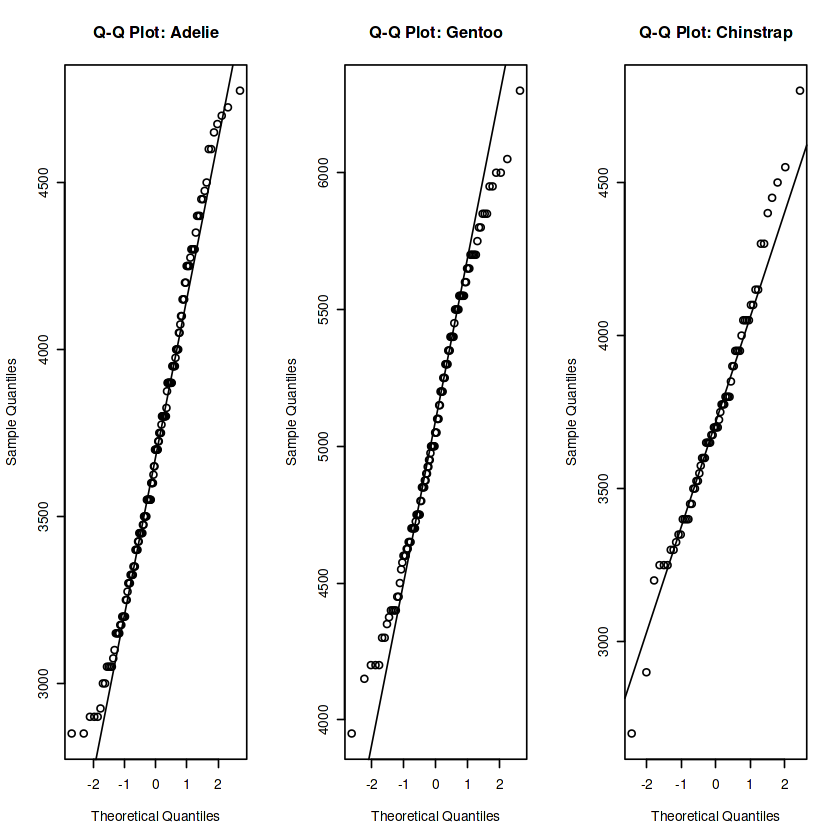

In [25]:
par(mfrow = c(1, 3))

for (sp in unique(analysis_data$species)) {
  
  values <- analysis_data %>%
    filter(species == sp) %>%
    pull(body_mass_g)
  
  qqnorm(
    values,
    main = paste("Q-Q Plot:", sp)
  )
  
  qqline(values)
}

par(mfrow = c(1, 1))

## 21. Shapiro-Wilk Test by Species

In [26]:
species_normality <- analysis_data %>%
  group_by(species) %>%
  shapiro_test(body_mass_g)

species_normality

species,variable,statistic,p
<fct>,<chr>,<dbl>,<dbl>
Adelie,body_mass_g,0.9811608,0.0423224
Chinstrap,body_mass_g,0.9844938,0.5605082
Gentoo,body_mass_g,0.9860612,0.2605247


## 22. Levene's Test for Homogeneity of Variance

### Hypotheses

**H₀:** The variances of body mass are equal across species.

**H₁:** The variances are not equal across species.

At α = 0.05:

- p-value > 0.05: Homogeneity assumption is supported
- p-value ≤ 0.05: Homogeneity assumption is violated

In [27]:
levene_body_mass <- leveneTest(
  body_mass_g ~ species,
  data = analysis_data
)

levene_body_mass

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,5.134899,0.006367054
,330,NA,NA


## 23. One-Way ANOVA

The model used is:

$$
body\_mass\_g \sim species
$$

In [28]:
one_way_anova <- aov(
  body_mass_g ~ species,
  data = analysis_data
)

summary(one_way_anova)

             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

## 24. ANOVA Table

The ANOVA table reports:

- Degrees of freedom
- Sum of squares
- Mean squares
- F-statistic
- p-value

In [29]:
anova_table <- summary(one_way_anova)[[1]]

anova_table

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
species,2,145190219,72595109.6,341.8949,3.744505e-81
Residuals,330,70069447,212331.7,NA,NA


In [30]:
F_statistic <- anova_table["species", "F value"]
df_species <- anova_table["species", "Df"]
df_residual <- anova_table["Residuals", "Df"]
anova_p <- anova_table["species", "Pr(>F)"]

cat("F-statistic =", round(F_statistic, 4), "\n")
cat("Degrees of freedom =", df_species, ",", df_residual, "\n")
cat("p-value =", format.pval(anova_p, digits = 5), "\n")

F-statistic = 341.8949 
Degrees of freedom = 2 , 330 
p-value = < 2.22e-16 


## 25. Tukey HSD Post-Hoc Test

Tukey's HSD test is performed to identify which pairs of species differ significantly when the overall ANOVA is significant.

In [31]:
tukey_body_mass <- TukeyHSD(one_way_anova)
tukey_body_mass

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = analysis_data)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000


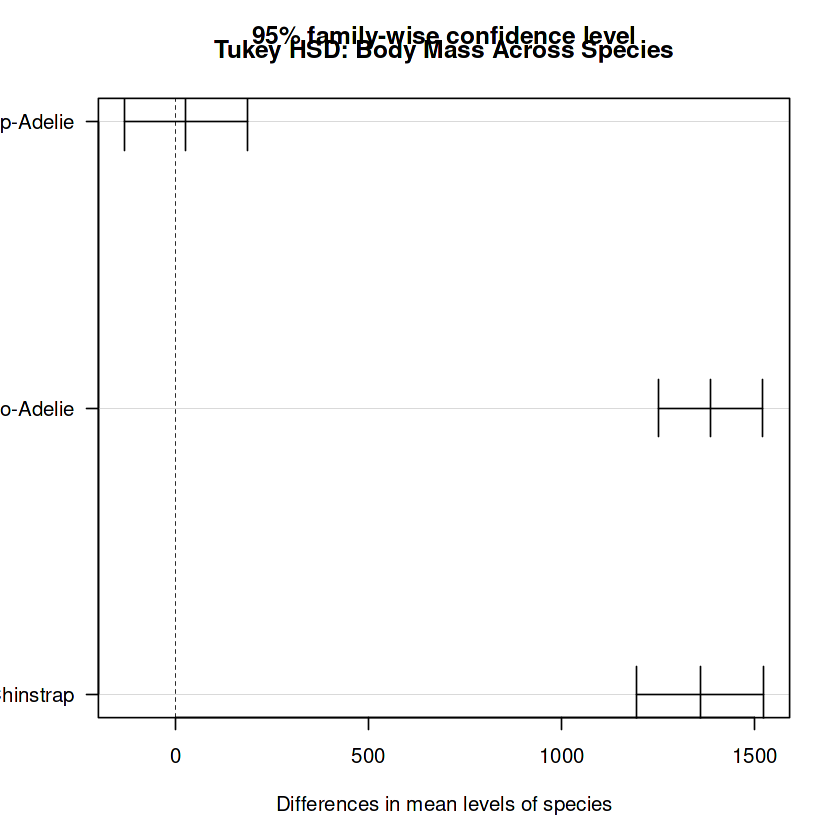

In [56]:
plot(
  tukey_body_mass,
  las = 1
)

title(
  main = "Tukey HSD: Body Mass Across Species"
)

# Task 4: Non-Parametric Analysis

The Kruskal-Wallis test is used as a non-parametric alternative to one-way ANOVA.

### Null Hypothesis (H₀)

The distributions of body mass are the same across all species.

### Alternative Hypothesis (H₁)

At least one species has a different distribution of body mass.

## 26. Kruskal-Wallis Test

In [34]:
kruskal_body_mass <- kruskal.test(
  body_mass_g ~ species,
  data = analysis_data
)

kruskal_body_mass


	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16


## 27. ANOVA and Kruskal-Wallis Comparison

In [35]:
comparison <- data.frame(
  Test = c(
    "One-Way ANOVA",
    "Kruskal-Wallis"
  ),
  Statistic = c(
    unname(anova_table["species", "F value"]),
    unname(kruskal_body_mass$statistic)
  ),
  P_Value = c(
    anova_p,
    kruskal_body_mass$p.value
  )
)

comparison

Test,Statistic,P_Value
<chr>,<dbl>,<dbl>
One-Way ANOVA,341.8949,3.744505e-81
Kruskal-Wallis,212.0851,8.836877e-47


## Interpretation

The conclusions from the One-Way ANOVA and Kruskal-Wallis test are compared.

If both tests reject the null hypothesis at α = 0.05, the evidence that body mass differs among penguin species is consistent across parametric and non-parametric methods.

# Task 5: Two-Way ANOVA

The simultaneous effects of species and sex on body mass are investigated using:

$$
body\_mass\_g \sim species * sex
$$

The model evaluates:

1. Main effect of species
2. Main effect of sex
3. Species × sex interaction

In [36]:
two_way_anova <- aov(
  body_mass_g ~ species * sex,
  data = analysis_data
)

summary(two_way_anova)

             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

## 28. Two-Way ANOVA Table

In [37]:
two_way_table <- summary(two_way_anova)[[1]]
two_way_table

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
species,2,145190219,72595109.56,758.358072,1.540207e-123
sex,1,37090262,37090261.78,387.459976,1.902273e-57
species:sex,2,1676557,838278.37,8.756997,1.973489e-04
Residuals,327,31302628,95726.69,NA,NA


## 29. Species × Sex Interaction Plot

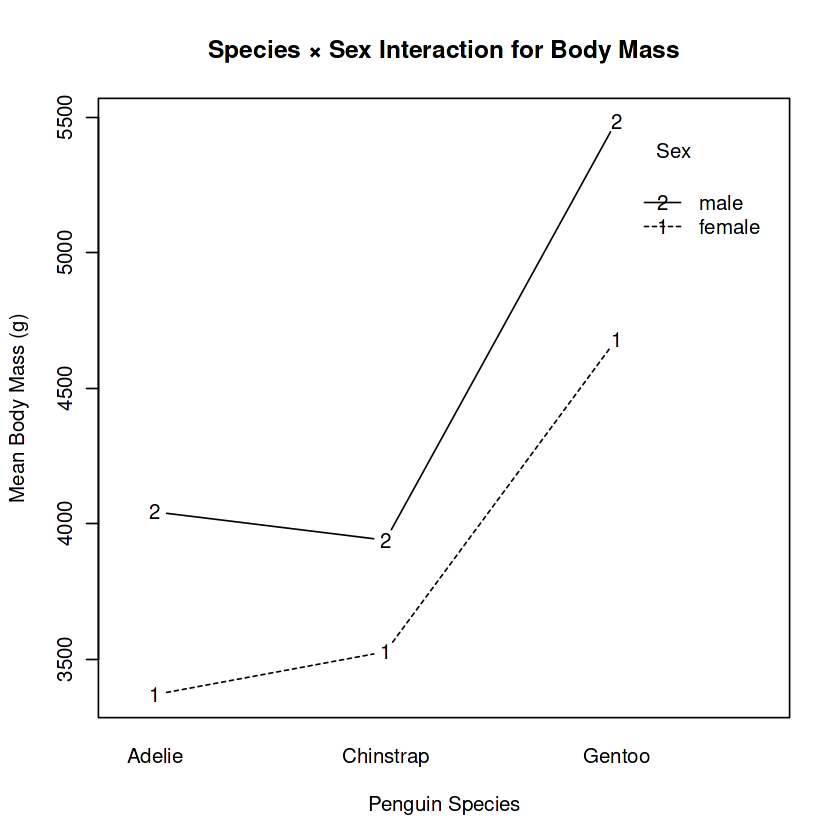

In [38]:
interaction.plot(
  x.factor = analysis_data$species,
  trace.factor = analysis_data$sex,
  response = analysis_data$body_mass_g,
  fun = mean,
  type = "b",
  xlab = "Penguin Species",
  ylab = "Mean Body Mass (g)",
  trace.label = "Sex",
  main = "Species × Sex Interaction for Body Mass"
)

## 30. Body Mass by Species and Sex

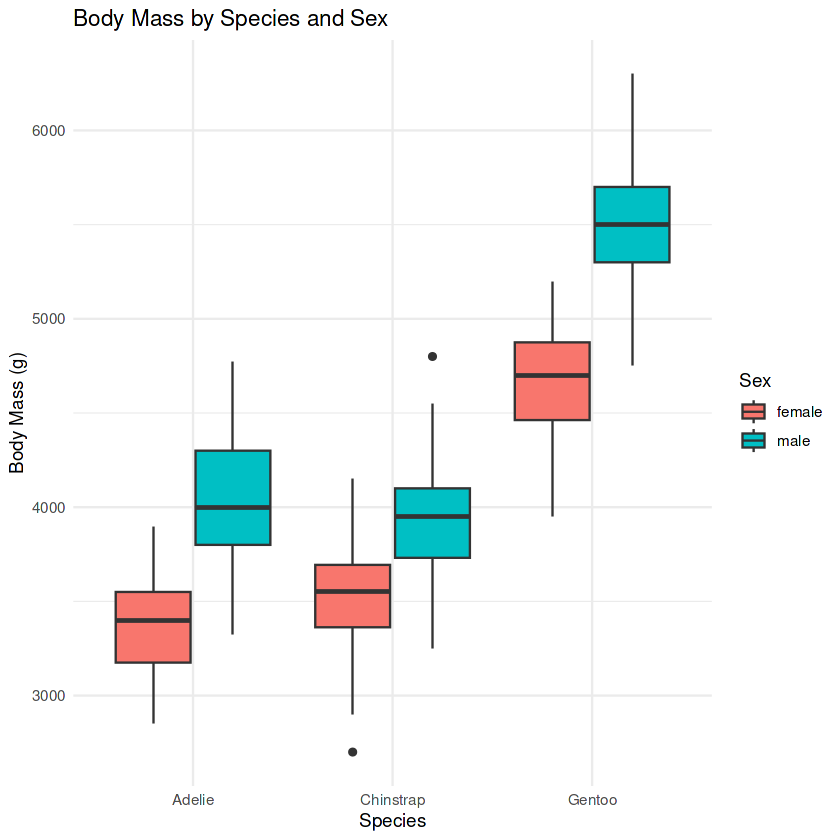

In [39]:
ggplot(
  analysis_data,
  aes(
    x = species,
    y = body_mass_g,
    fill = sex
  )
) +
  geom_boxplot(
    position = position_dodge(width = 0.8)
  ) +
  labs(
    title = "Body Mass by Species and Sex",
    x = "Species",
    y = "Body Mass (g)",
    fill = "Sex"
  ) +
  theme_minimal()

## 31. Interpretation of Two-Way ANOVA

The p-values for species, sex, and species × sex interaction are examined.

- A significant species effect indicates differences in body mass among species.
- A significant sex effect indicates differences in body mass between sexes.
- A significant species × sex interaction indicates that the effect of sex depends on species.

# Task 6: Additional Analysis Using Flipper Length

The analysis is repeated using flipper length to investigate whether mean flipper length differs among the three penguin species.

### Null Hypothesis (H₀)

$$
\mu_{Adelie} = \mu_{Chinstrap} = \mu_{Gentoo}
$$

### Alternative Hypothesis (H₁)

At least one species has a different mean flipper length.

## 32. Descriptive Statistics of Flipper Length

In [40]:
flipper_summary <- analysis_data %>%
  group_by(species) %>%
  summarise(
    N = n(),
    Mean = mean(flipper_length_mm),
    Median = median(flipper_length_mm),
    Minimum = min(flipper_length_mm),
    Maximum = max(flipper_length_mm),
    Variance = var(flipper_length_mm),
    Standard_Deviation = sd(flipper_length_mm),
    Q1 = quantile(flipper_length_mm, 0.25),
    Q3 = quantile(flipper_length_mm, 0.75),
    IQR = IQR(flipper_length_mm),
    Skewness = skewness(flipper_length_mm),
    Kurtosis = kurtosis(flipper_length_mm),
    .groups = "drop"
  )

flipper_summary

species,N,Mean,Median,Minimum,Maximum,Variance,Standard_Deviation,Q1,Q3,IQR,Skewness,Kurtosis
<fct>,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Adelie,146,190.1027,190,172,210,42.53420,6.521825,186,195.0,9.0,0.079578511,3.327738
Chinstrap,68,195.8235,196,178,212,50.86392,7.131894,191,201.0,10.0,-0.009262203,2.956063
Gentoo,119,217.2353,216,203,231,43.36790,6.585431,212,221.5,9.5,0.364085778,2.322009


## 33. Species-Wise Flipper Length Comparison

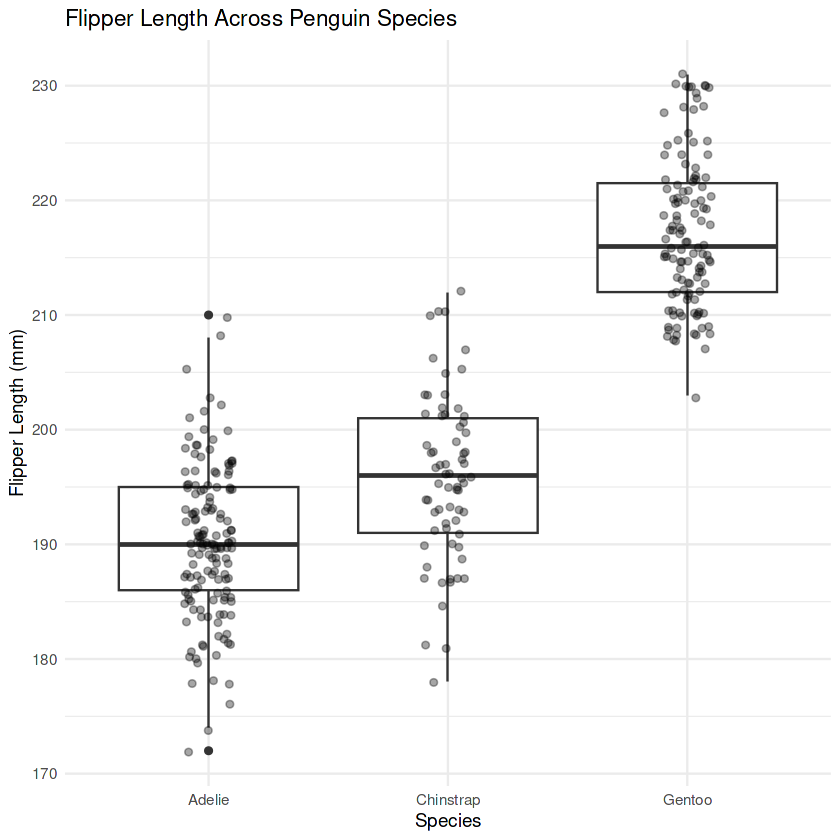

In [41]:
ggplot(
  analysis_data,
  aes(
    x = species,
    y = flipper_length_mm
  )
) +
  geom_boxplot() +
  geom_jitter(
    width = 0.1,
    alpha = 0.35
  ) +
  labs(
    title = "Flipper Length Across Penguin Species",
    x = "Species",
    y = "Flipper Length (mm)"
  ) +
  theme_minimal()

## 34. Q-Q Plots for Flipper Length

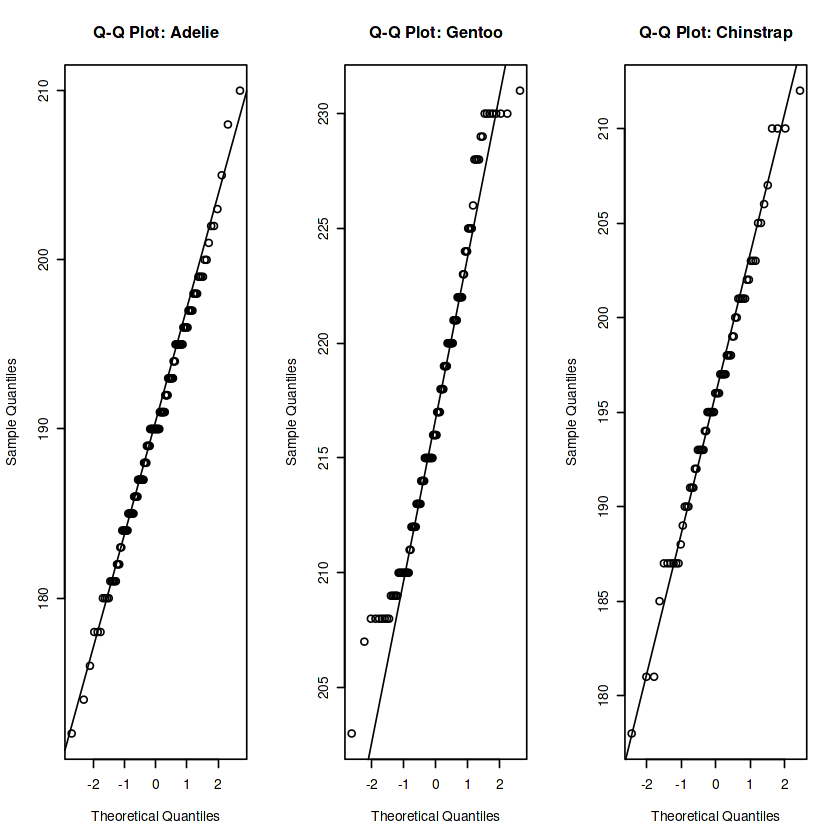

In [42]:
par(mfrow = c(1, 3))

for (sp in unique(analysis_data$species)) {
  
  values <- analysis_data %>%
    filter(species == sp) %>%
    pull(flipper_length_mm)
  
  qqnorm(
    values,
    main = paste("Q-Q Plot:", sp)
  )
  
  qqline(values)
}

par(mfrow = c(1, 1))

## 35. Shapiro-Wilk Test for Flipper Length

In [43]:
flipper_normality <- analysis_data %>%
  group_by(species) %>%
  shapiro_test(flipper_length_mm)

flipper_normality

species,variable,statistic,p
<fct>,<chr>,<dbl>,<dbl>
Adelie,flipper_length_mm,0.9934049,0.742742565
Chinstrap,flipper_length_mm,0.9889115,0.810644659
Gentoo,flipper_length_mm,0.9614772,0.001759983


## 36. Levene's Test for Flipper Length

In [44]:
levene_flipper <- leveneTest(
  flipper_length_mm ~ species,
  data = analysis_data
)

levene_flipper

,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,0.4427865,0.6426253
,330,NA,NA


## 37. One-Way ANOVA for Flipper Length

In [45]:
flipper_anova <- aov(
  flipper_length_mm ~ species,
  data = analysis_data
)

summary(flipper_anova)

             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  50526   25263   567.4 <2e-16 ***
Residuals   330  14693      45                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [46]:
flipper_anova_table <- summary(flipper_anova)[[1]]

flipper_anova_table

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
species,2,50525.88,25262.94181,567.407,1.587418e-107
Residuals,330,14692.75,44.52349,NA,NA


## 38. Tukey HSD for Flipper Length

In [47]:
flipper_tukey <- TukeyHSD(flipper_anova)

flipper_tukey

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = analysis_data)

$species
                     diff       lwr       upr p adj
Chinstrap-Adelie  5.72079  3.414364  8.027215     0
Gentoo-Adelie    27.13255 25.192399 29.072709     0
Gentoo-Chinstrap 21.41176 19.023644 23.799885     0


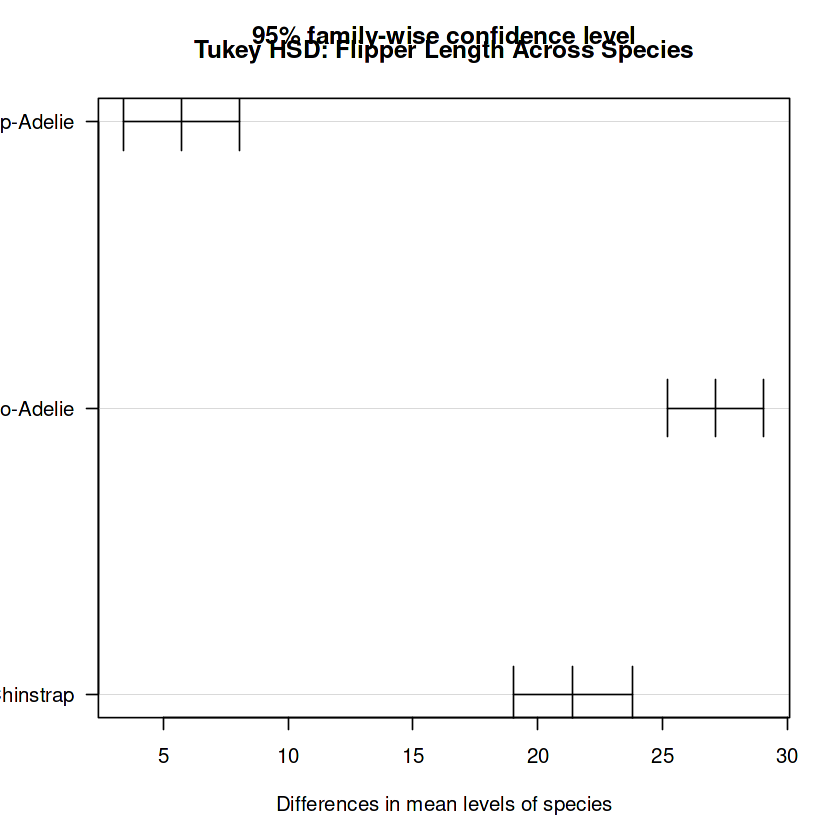

In [57]:
plot(
  flipper_tukey,
  las = 1
)

title(
  main = "Tukey HSD: Flipper Length Across Species"
)

## 39. Kruskal-Wallis Test for Flipper Length

In [49]:
flipper_kruskal <- kruskal.test(
  flipper_length_mm ~ species,
  data = analysis_data
)

flipper_kruskal


	Kruskal-Wallis rank sum test

data:  flipper_length_mm by species
Kruskal-Wallis chi-squared = 237.35, df = 2, p-value < 2.2e-16


# Task 7: Visualization and Interpretation

The following visualizations summarize the statistical analysis:

- Histogram of body mass
- Density plot of body mass
- Species-wise body mass boxplot
- Sex-wise body mass boxplot
- Q-Q plots
- Species × sex interaction plot
- Body mass comparison by species and sex
- Species-wise flipper-length comparison
- Tukey HSD plots

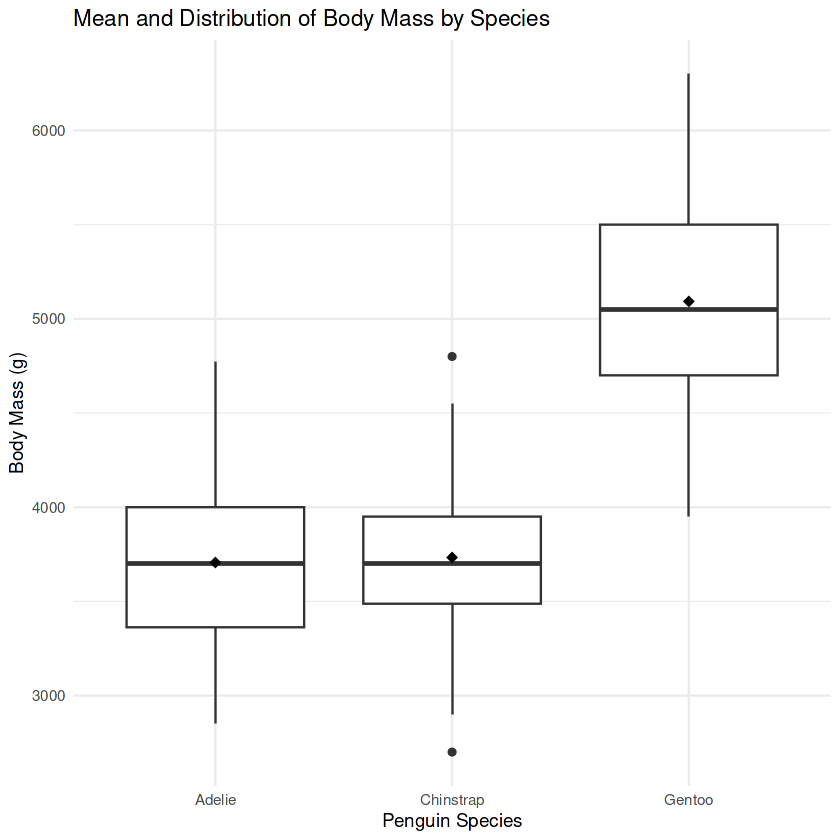

In [50]:
ggplot(
  analysis_data,
  aes(
    x = species,
    y = body_mass_g
  )
) +
  geom_boxplot() +
  stat_summary(
    fun = mean,
    geom = "point",
    shape = 18,
    size = 3
  ) +
  labs(
    title = "Mean and Distribution of Body Mass by Species",
    x = "Penguin Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()

# 41. Final Statistical Results

The major statistical results are summarized below.

Analysis,Statistic,P_Value
<chr>,<chr>,<chr>
Male vs Female Body Mass,t = -8.555,4.794e-16
One-Way ANOVA: Body Mass,F = 341.895,< 2.2e-16
Kruskal-Wallis: Body Mass,Chi-square = 212.085,< 2.2e-16
Two-Way ANOVA: Species,F = NA,NA
Two-Way ANOVA: Sex,F = 387.46,< 2.2e-16
Two-Way ANOVA: Species × Sex,F = 8.757,0.0001973
One-Way ANOVA: Flipper Length,F = 567.407,< 2.2e-16
Kruskal-Wallis: Flipper Length,Chi-square = 237.346,< 2.2e-16


In [62]:
# Extract two-way ANOVA p-values
species_p <- two_way_table["species", "Pr(>F)"]
sex_p <- two_way_table["sex", "Pr(>F)"]
interaction_p <- two_way_table["species:sex", "Pr(>F)"]

# Extract flipper ANOVA values
flipper_F <- flipper_anova_table["species", "F value"]
flipper_p <- flipper_anova_table["species", "Pr(>F)"]

final_results <- data.frame(
  Analysis = c(
    "Male vs Female Body Mass",
    "One-Way ANOVA: Body Mass",
    "Kruskal-Wallis: Body Mass",
    "Two-Way ANOVA: Species",
    "Two-Way ANOVA: Sex",
    "Two-Way ANOVA: Species × Sex",
    "One-Way ANOVA: Flipper Length",
    "Kruskal-Wallis: Flipper Length"
  ),
  
  Statistic = c(
    paste0("t = ", round(t_test$statistic, 3)),
    paste0("F = ", round(F_statistic, 3)),
    paste0("Chi-square = ", round(kruskal_body_mass$statistic, 3)),
    paste0("F = ", round(two_way_table["species", "F value"], 3)),
    paste0("F = ", round(two_way_table["sex", "F value"], 3)),
    paste0("F = ", round(two_way_table["species:sex", "F value"], 3)),
    paste0("F = ", round(flipper_F, 3)),
    paste0("Chi-square = ", round(flipper_kruskal$statistic, 3))
  ),
  
  P_Value = c(
    t_test$p.value,
    anova_p,
    kruskal_body_mass$p.value,
    species_p,
    sex_p,
    interaction_p,
    flipper_p,
    flipper_kruskal$p.value
  )
)

final_results

Analysis,Statistic,P_Value
<chr>,<chr>,<dbl>
Male vs Female Body Mass,t = -8.555,4.793891e-16
One-Way ANOVA: Body Mass,F = 341.895,3.744505e-81
Kruskal-Wallis: Body Mass,Chi-square = 212.085,8.836877e-47
Two-Way ANOVA: Species,F = NA,NA
Two-Way ANOVA: Sex,F = 387.46,1.902273e-57
Two-Way ANOVA: Species × Sex,F = 8.757,1.973489e-04
One-Way ANOVA: Flipper Length,F = 567.407,1.587418e-107
Kruskal-Wallis: Flipper Length,Chi-square = 237.346,2.890851e-52


# 42. Conclusion

The Palmer Penguins dataset was analyzed using descriptive and inferential statistical methods.

The analysis included descriptive statistics, distribution visualization, normality testing, an independent two-sample Welch t-test, confidence interval estimation, Cohen's d effect size, one-way ANOVA, Levene's test, Tukey's HSD post-hoc analysis, Kruskal-Wallis testing, and two-way ANOVA.

The analysis was also extended to flipper length to determine whether physical differences among penguin species were consistent across different characteristics.

The final conclusions are based on the calculated p-values, confidence intervals, effect sizes, ANOVA results, post-hoc comparisons, and graphical analysis.